## Model Evaluation
### This code helps us answer some of the question about the model evaluation such as:
- How to measure prediction error
- Why multiple evaluation metrics are needed
- What MAE, MSE, RMSE, and R² actually mean
- How to analyze residuals
- How to identify systematic errors

#### 1. Residual: This is basically the difference between the predicted and the actual value

In [1]:
# import relevant packages/libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [4]:
# Test and train samples
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # size of the testing data
    random_state=42 # randomize the dataset to avoid any bias in selecting the dataset
)

In [5]:
# Scaling the sample
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
# Training the model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [11]:
# Testing the model
y_actual = y_test
y_pred = pipeline.predict(X_test)

model = pipeline.named_steps["model"]

print("Intercept:", model.intercept_)

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef)

Intercept: 2.0719469373788777
      Feature  Coefficient
0      MedInc     0.854383
1    HouseAge     0.122546
2    AveRooms    -0.294410
3   AveBedrms     0.339259
4  Population    -0.002308
5    AveOccup    -0.040829
6    Latitude    -0.896929
7   Longitude    -0.869842


#### Calculate the mean absolute error, mean squared error, root mean square error and R2 score. R2 score is the most reported metric in ML.

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -------------------------
# Absolute Mean Error
# -------------------------

mae = mean_absolute_error(
    y_test,
    y_pred
)

# -------------------------
# Mean Squared Error
# -------------------------

mse = mean_squared_error(
    y_test,
    y_pred
)

# -------------------------
# Root Mean Square Error
# -------------------------

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

# -------------------------
# Residual Calculation
# -------------------------

residuals = y_test - y_pred

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")
# print(f"Residual: {residual}")

MAE  : 0.533
MSE  : 0.556
RMSE : 0.746
R²   : 0.576


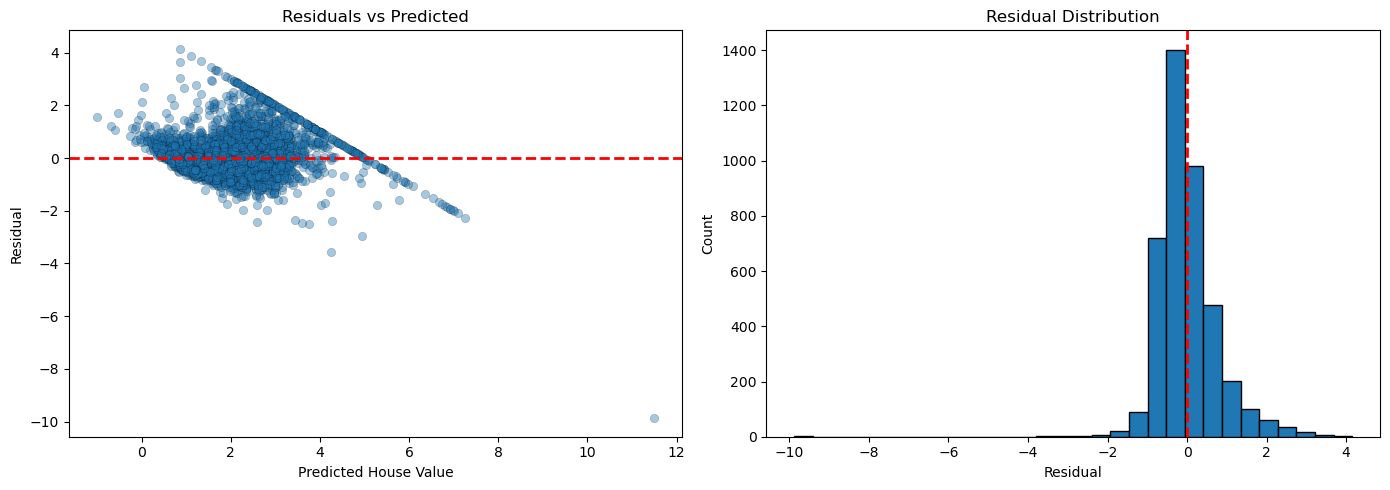

In [35]:
### Plot the residual vs prediction as a scatter plot and the histogram
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Residual Scatter Plot
# -------------------------
axes[0].scatter(y_pred, residuals,
                alpha=0.4,
                edgecolor='k',
                linewidth=0.3)

axes[0].axhline(y=0,
                color='red',
                linestyle='--',
                linewidth=2)

axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted House Value")
axes[0].set_ylabel("Residual")

# -------------------------
# Residual Histogram
# -------------------------
axes[1].hist(residuals,
             bins=30,
             edgecolor='black')

axes[1].axvline(x=0,
                color='red',
                linestyle='--',
                linewidth=2)

axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
# Improve layout
plt.tight_layout()

plt.show()

### As we can see the distribution is centered around zero, therefore the model is working good.